In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os

# Connessione al database
BASE_DIR = os.path.dirname(os.path.abspath(''))
DB_PATH = os.path.join(BASE_DIR, 'db', 'nuclear.db')
conn = sqlite3.connect(DB_PATH)

# Stile grafici
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Setup completato")
print(f"Database: {DB_PATH}")

Setup completato
Database: C:\Users\giuse\Documents\nuclear-data-analysis\db\nuclear.db


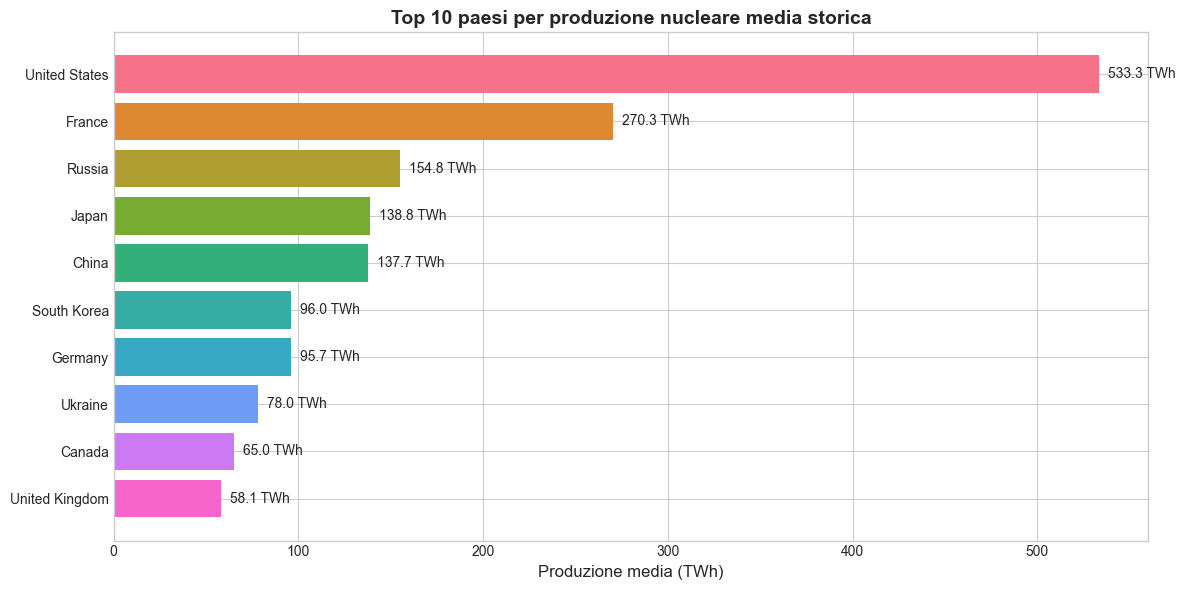

Grafico salvato in plots/


In [2]:
# Leggi i dati dal database con una query SQL
query = """
    SELECT country, ROUND(AVG(nuclear_twh), 1) as media_twh
    FROM nuclear_generation
    WHERE nuclear_twh > 0
    GROUP BY country
    ORDER BY media_twh DESC
    LIMIT 10
"""
df_top10 = pd.read_sql(query, conn)

# Grafico
fig, ax = plt.subplots(figsize=(12, 6))

bars = ax.barh(df_top10['country'], df_top10['media_twh'], 
               color=sns.color_palette('husl', 10))

# Etichette valori sulle barre
for bar, val in zip(bars, df_top10['media_twh']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val} TWh', va='center', fontsize=10)

ax.set_xlabel('Produzione media (TWh)', fontsize=12)
ax.set_title('Top 10 paesi per produzione nucleare media storica', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../plots/01_top10_produttori.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")

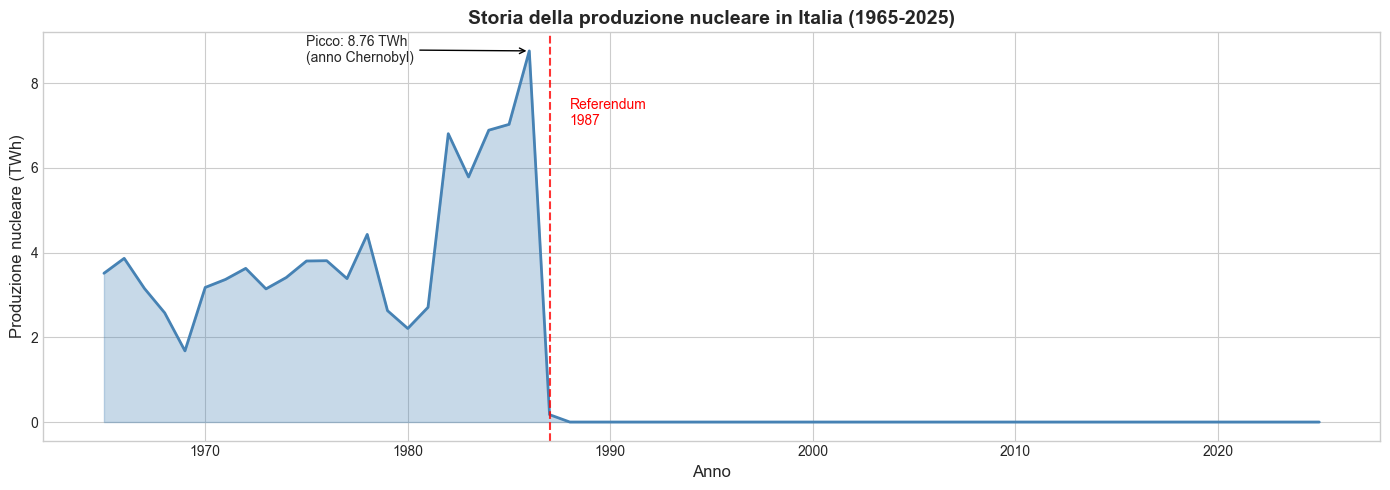

Grafico salvato in plots/


In [3]:
query = """
    SELECT year, nuclear_twh
    FROM nuclear_generation
    WHERE country = 'Italy'
    ORDER BY year
"""
df_italy = pd.read_sql(query, conn)

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(df_italy['year'], df_italy['nuclear_twh'], 
                alpha=0.3, color='steelblue')
ax.plot(df_italy['year'], df_italy['nuclear_twh'], 
        color='steelblue', linewidth=2)

# Linea verticale referendum
ax.axvline(x=1987, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
ax.text(1988, 7, 'Referendum\n1987', color='red', fontsize=10)

# Punto picco
ax.annotate('Picco: 8.76 TWh\n(anno Chernobyl)',
            xy=(1986, 8.758), xytext=(1975, 8.5),
            arrowprops=dict(arrowstyle='->', color='black'),
            fontsize=10)

ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Produzione nucleare (TWh)', fontsize=12)
ax.set_title('Storia della produzione nucleare in Italia (1965-2025)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/02_italia_storia.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")

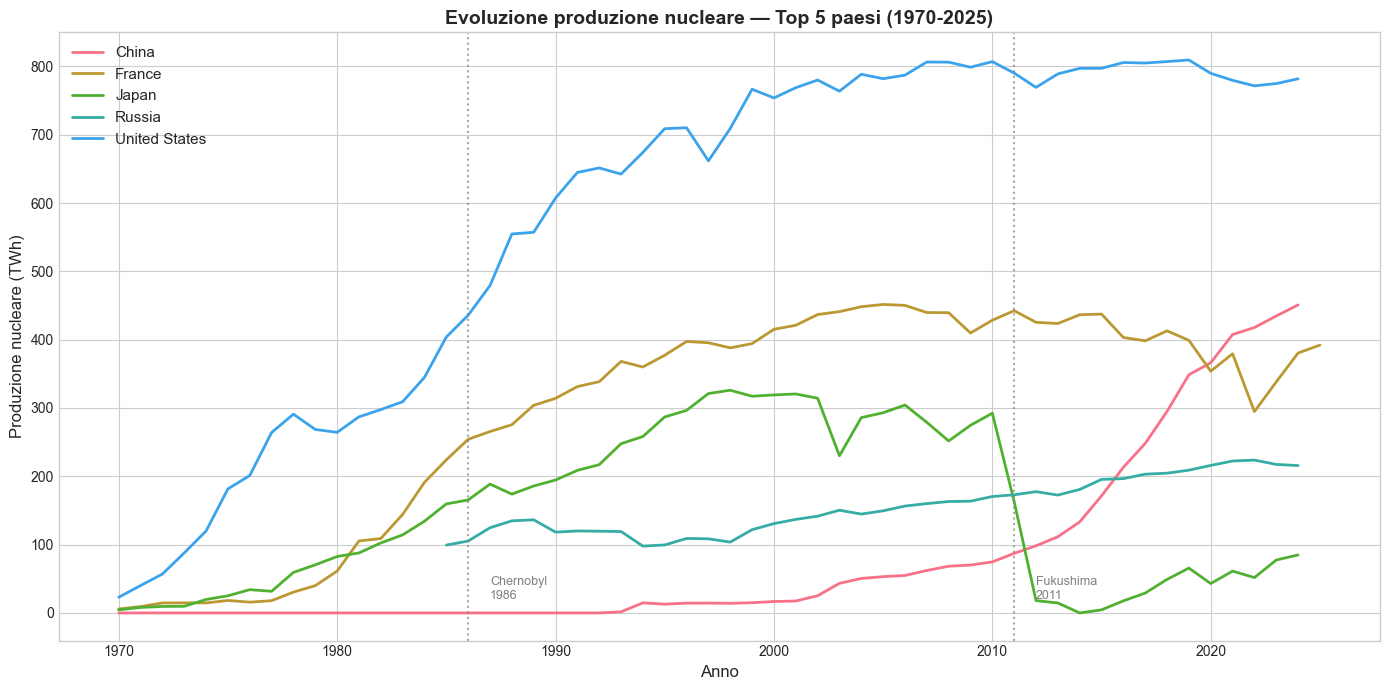

Grafico salvato in plots/


In [4]:
query = """
    SELECT country, year, nuclear_twh
    FROM nuclear_generation
    WHERE country IN ('United States', 'France', 'Russia', 'China', 'Japan')
    AND year >= 1970
    ORDER BY country, year
"""
df_trend = pd.read_sql(query, conn)

fig, ax = plt.subplots(figsize=(14, 7))

for country in df_trend['country'].unique():
    df_c = df_trend[df_trend['country'] == country]
    ax.plot(df_c['year'], df_c['nuclear_twh'], linewidth=2, label=country)

# Linea Chernobyl
ax.axvline(x=1986, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(1987, 20, 'Chernobyl\n1986', color='gray', fontsize=9)

# Linea Fukushima
ax.axvline(x=2011, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(2012, 20, 'Fukushima\n2011', color='gray', fontsize=9)

ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Produzione nucleare (TWh)', fontsize=12)
ax.set_title('Evoluzione produzione nucleare — Top 5 paesi (1970-2025)', 
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../plots/03_trend_top5.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")

In [5]:
query = """
    SELECT year, nuclear_electricity, nuclear_share_elec, 
           nuclear_share_energy, population
    FROM nuclear_indicators
    WHERE country = 'Italy'
    ORDER BY year
"""
df_italy_ind = pd.read_sql(query, conn)

print(f"Anni disponibili: {df_italy_ind['year'].min()} - {df_italy_ind['year'].max()}")
print(f"Righe totali: {len(df_italy_ind)}")
print("\nPrime righe con dati non nulli:")
print(df_italy_ind[df_italy_ind['nuclear_share_elec'].notna()].head(10))

Anni disponibili: 1900 - 2025
Righe totali: 126

Prime righe con dati non nulli:
    year  nuclear_electricity  nuclear_share_elec  nuclear_share_energy  \
85  1985                7.024               3.782                 1.197   
86  1986                8.758               4.554                 1.453   
87  1987                0.174               0.086                 0.028   
88  1988                0.000               0.000                 0.000   
89  1989                0.000               0.000                 0.000   
90  1990                0.000               0.000                 0.000   
91  1991                0.000               0.000                 0.000   
92  1992                0.000               0.000                 0.000   
93  1993                0.000               0.000                 0.000   
94  1994                0.000               0.000                 0.000   

    population  
85  56855499.0  
86  56875982.0  
87  56891919.0  
88  56928748.0  
89  5697

In [6]:
# Rileggiamo il CSV completo perché contiene tutte le fonti energetiche
df_owid = pd.read_csv('../data/raw/owid-energy-data.csv')

# Filtriamo solo l'Italia
cols_italia = ['year', 'nuclear_electricity', 'coal_electricity', 
               'gas_electricity', 'oil_electricity', 'hydro_electricity',
               'solar_electricity', 'wind_electricity', 
               'renewables_electricity', 'electricity_generation']

df_it = df_owid[df_owid['country'] == 'Italy'][cols_italia].copy()
df_it = df_it[df_it['year'] >= 1965].sort_values('year')

print(f"Anni disponibili: {df_it['year'].min()} - {df_it['year'].max()}")
print(f"\nPrime righe:")
print(df_it[df_it['electricity_generation'].notna()].head(10))

Anni disponibili: 1965 - 2025

Prime righe:
       year  nuclear_electricity  coal_electricity  gas_electricity  \
10345  1985                7.024            30.023           24.712   
10346  1986                8.758            31.004           26.871   
10347  1987                0.174            33.035           31.732   
10348  1988                0.000            33.897           32.420   
10349  1989                0.000            31.867           34.407   
10350  1990                0.000            32.050           39.710   
10351  1991                0.000            28.500           36.340   
10352  1992                0.000            21.360           35.480   
10353  1993                0.000            16.660           39.960   
10354  1994                0.000            19.860           40.800   

       oil_electricity  hydro_electricity  solar_electricity  \
10345           76.174             41.092              0.000   
10346           77.483             41.096     

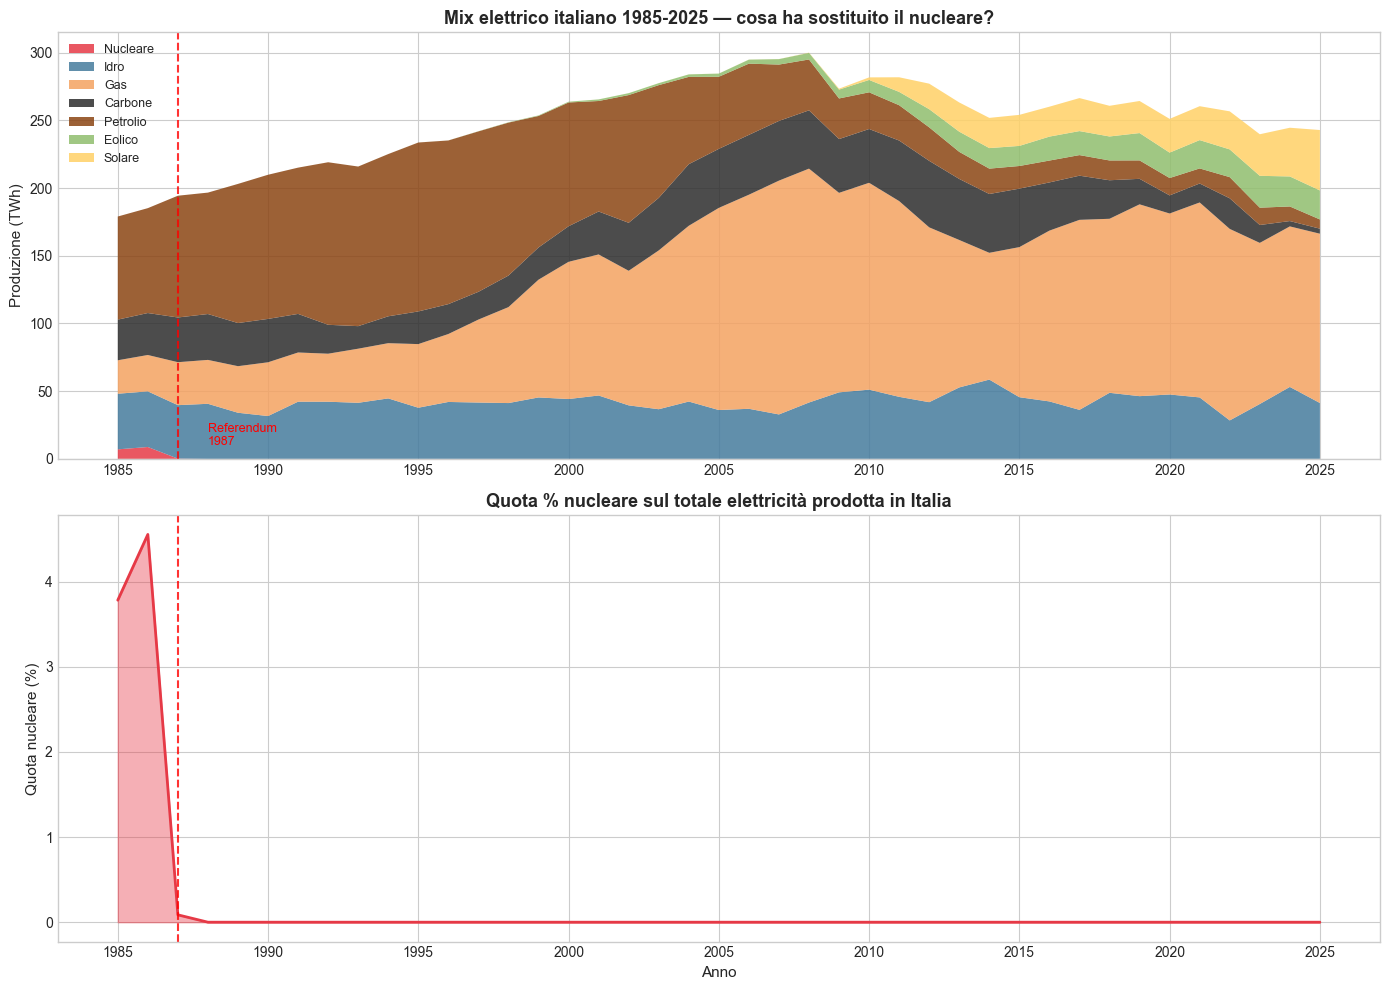

Grafico salvato in plots/


In [7]:
df_plot = df_it[df_it['electricity_generation'].notna()].copy()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# --- Grafico superiore: area chart mix energetico ---
ax1 = axes[0]

ax1.stackplot(df_plot['year'],
              df_plot['nuclear_electricity'].fillna(0),
              df_plot['hydro_electricity'].fillna(0),
              df_plot['gas_electricity'].fillna(0),
              df_plot['coal_electricity'].fillna(0),
              df_plot['oil_electricity'].fillna(0),
              df_plot['wind_electricity'].fillna(0),
              df_plot['solar_electricity'].fillna(0),
              labels=['Nucleare', 'Idro', 'Gas', 'Carbone', 'Petrolio', 'Eolico', 'Solare'],
              colors=['#e63946', '#457b9d', '#f4a261', '#2d2d2d', '#8B4513', '#90be6d', '#ffd166'],
              alpha=0.85)

ax1.axvline(x=1987, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
ax1.text(1988, 10, 'Referendum\n1987', color='red', fontsize=9)
ax1.set_ylabel('Produzione (TWh)', fontsize=11)
ax1.set_title('Mix elettrico italiano 1985-2025 — cosa ha sostituito il nucleare?', 
              fontsize=13, fontweight='bold')
ax1.legend(loc='upper left', fontsize=9)

# --- Grafico inferiore: quota % nucleare ---
ax2 = axes[1]

# Calcola quota nucleare sul totale
df_plot['quota_nucleare'] = (df_plot['nuclear_electricity'].fillna(0) / 
                              df_plot['electricity_generation'] * 100)

ax2.fill_between(df_plot['year'], df_plot['quota_nucleare'],
                 alpha=0.4, color='#e63946')
ax2.plot(df_plot['year'], df_plot['quota_nucleare'],
         color='#e63946', linewidth=2)
ax2.axvline(x=1987, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
ax2.set_xlabel('Anno', fontsize=11)
ax2.set_ylabel('Quota nucleare (%)', fontsize=11)
ax2.set_title('Quota % nucleare sul totale elettricità prodotta in Italia', 
              fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../plots/02b_italia_mix_energetico.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")

In [8]:
query = """
    SELECT 
        CASE WHEN year <= 1987 THEN 'Prima (1985-1987)' 
             WHEN year >= 2000 THEN 'Dopo (2000-2010)'
             ELSE NULL END as periodo,
        ROUND(AVG(nuclear_twh), 2) as media_nucleare
    FROM nuclear_generation
    WHERE country = 'Italy'
    AND (year <= 1987 OR (year >= 2000 AND year <= 2010))
    GROUP BY periodo
"""
df_confronto = pd.read_sql(query, conn)
print(df_confronto)

# Dal CSV OWID calcoliamo la crescita del gas
gas_prima = df_it[df_it['year'] <= 1987]['gas_electricity'].mean()
gas_dopo = df_it[(df_it['year'] >= 2000) & (df_it['year'] <= 2010)]['gas_electricity'].mean()
oil_prima = df_it[df_it['year'] <= 1987]['oil_electricity'].mean()
oil_dopo = df_it[(df_it['year'] >= 2000) & (df_it['year'] <= 2010)]['oil_electricity'].mean()

print(f"\nGas — prima: {gas_prima:.1f} TWh → dopo: {gas_dopo:.1f} TWh (+{gas_dopo-gas_prima:.1f} TWh)")
print(f"Petrolio — prima: {oil_prima:.1f} TWh → dopo: {oil_dopo:.1f} TWh (+{oil_dopo-oil_prima:.1f} TWh)")

             periodo  media_nucleare
0   Dopo (2000-2010)            0.00
1  Prima (1985-1987)            3.91

Gas — prima: 27.8 TWh → dopo: 136.8 TWh (+109.1 TWh)
Petrolio — prima: 81.2 TWh → dopo: 59.8 TWh (+-21.4 TWh)


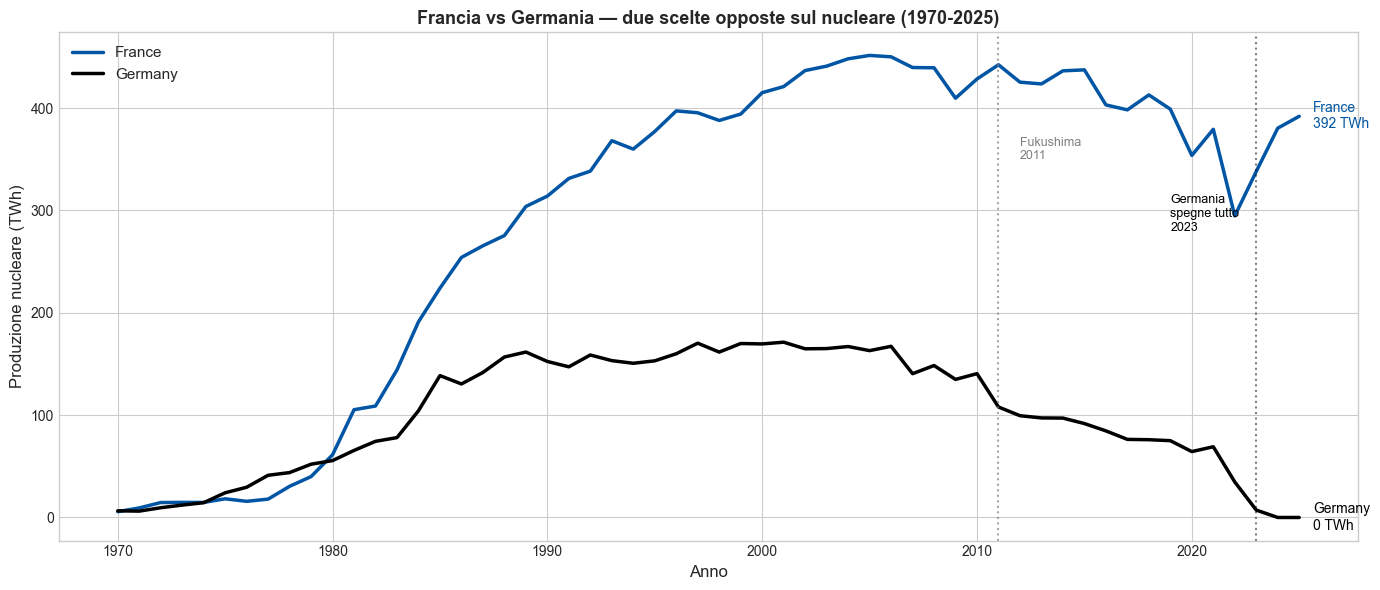

Grafico salvato in plots/


In [9]:
query = """
    SELECT country, year, nuclear_twh
    FROM nuclear_generation
    WHERE country IN ('France', 'Germany')
    AND year >= 1970
    ORDER BY country, year
"""
df_frvde = pd.read_sql(query, conn)

fig, ax = plt.subplots(figsize=(14, 6))

for country, color in [('France', '#0055A4'), ('Germany', '#000000')]:
    df_c = df_frvde[df_frvde['country'] == country]
    ax.plot(df_c['year'], df_c['nuclear_twh'], 
            linewidth=2.5, label=country, color=color)
    # Etichetta finale
    last = df_c.iloc[-1]
    ax.annotate(f"{country}\n{last['nuclear_twh']:.0f} TWh",
                xy=(last['year'], last['nuclear_twh']),
                xytext=(10, 0), textcoords='offset points',
                fontsize=10, color=color, va='center')

# Evento Fukushima
ax.axvline(x=2011, color='gray', linestyle=':', linewidth=1.5, alpha=0.7)
ax.text(2012, 350, 'Fukushima\n2011', color='gray', fontsize=9)

# Evento Energiewende Germania
ax.axvline(x=2023, color='black', linestyle=':', linewidth=1.5, alpha=0.5)
ax.text(2019, 280, 'Germania\nspegne tutto\n2023', color='black', fontsize=9)

ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Produzione nucleare (TWh)', fontsize=12)
ax.set_title('Francia vs Germania — due scelte opposte sul nucleare (1970-2025)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../plots/04_francia_vs_germania.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")

In [10]:
query = """
    SELECT country, 
           ROUND(nuclear_share_elec, 2) as quota_1987
    FROM nuclear_indicators
    WHERE year = 1987
    AND nuclear_share_elec > 0
    ORDER BY quota_1987 ASC
"""
df_benchmark = pd.read_sql(query, conn)
print("Paesi con dati nucleare nel 1987:")
print(df_benchmark.to_string())

Paesi con dati nucleare nel 1987:
           country  quota_1987
0            Italy        0.09
1           Brazil        0.48
2         Pakistan        0.84
3            India        2.38
4     South Africa        4.05
5      Netherlands        5.20
6           Russia       11.91
7        Argentina       12.40
8           Canada       15.56
9          Czechia       17.20
10   United States       17.29
11         Ukraine       17.91
12  United Kingdom       18.28
13           Japan       26.23
14         Germany       26.62
15        Bulgaria       28.61
16           Spain       31.11
17         Finland       36.80
18         Hungary       36.93
19     Switzerland       38.24
20       Lithuania       40.36
21          Sweden       45.97
22          Taiwan       47.89
23        Slovakia       48.72
24     South Korea       48.99
25         Belgium       66.23
26          France       70.15


In [11]:
query = """
    SELECT country, 
           ROUND(nuclear_share_elec, 2) as quota_1986
    FROM nuclear_indicators
    WHERE year = 1986
    AND nuclear_share_elec > 0
    ORDER BY quota_1986 ASC
"""
df_benchmark = pd.read_sql(query, conn)
print("Paesi con quota nucleare nel 1986:")
print(df_benchmark.to_string())

Paesi con quota nucleare nel 1986:
           country  quota_1986
0           Brazil        0.07
1         Pakistan        1.63
2            India        2.48
3            Italy        4.55
4     South Africa        5.94
5      Netherlands        6.28
6          Czechia       10.15
7           Russia       10.51
8        Argentina       11.65
9           Canada       15.21
10         Ukraine       15.66
11   United States       16.29
12  United Kingdom       19.62
13           Japan       24.45
14         Germany       24.92
15         Hungary       26.47
16        Bulgaria       28.86
17           Spain       29.14
18         Finland       38.70
19     Switzerland       39.06
20     South Korea       40.63
21          Taiwan       43.22
22       Lithuania       44.08
23        Slovakia       48.48
24          Sweden       50.45
25         Belgium       67.14
26          France       70.02


In [12]:
query = """
    SELECT country, ROUND(nuclear_twh, 2) as twh_1986
    FROM nuclear_generation
    WHERE year = 1986
    AND nuclear_twh > 0
    ORDER BY twh_1986 ASC
"""
df_twh86 = pd.read_sql(query, conn)
print("Produzione assoluta nucleare nel 1986 (TWh):")
print(df_twh86.to_string())

Produzione assoluta nucleare nel 1986 (TWh):
           country  twh_1986
0           Brazil      0.14
1         Pakistan      0.53
2      Netherlands      4.22
3            India      5.02
4        Argentina      5.71
5          Czechia      6.15
6          Hungary      7.42
7            Italy      8.76
8     South Africa      8.80
9        Lithuania      9.88
10        Slovakia     11.72
11        Bulgaria     12.07
12         Finland     18.95
13     Switzerland     22.42
14          Taiwan     26.94
15     South Korea     28.31
16           Spain     37.46
17         Belgium     39.39
18         Ukraine     42.71
19  United Kingdom     59.08
20          Sweden     69.95
21          Canada     71.27
22          Russia    105.22
23         Germany    130.49
24           Japan    165.37
25          France    254.16
26   United States    435.83


In [13]:
query = """
    SELECT country, year, nuclear_twh
    FROM nuclear_generation
    WHERE country IN ('Italy', 'South Africa', 'Hungary', 'Finland')
    AND year >= 1980
    ORDER BY country, year
"""
df_cf = pd.read_sql(query, conn)

# Verifica dati
for country in ['Italy', 'South Africa', 'Hungary', 'Finland']:
    df_c = df_cf[df_cf['country'] == country]
    print(f"{country}: {df_c['year'].min()}-{df_c['year'].max()} | "
          f"1986: {df_c[df_c['year']==1986]['nuclear_twh'].values[0]:.2f} TWh | "
          f"2023: {df_c[df_c['year']==2023]['nuclear_twh'].values[0]:.2f} TWh")

Italy: 1980-2025 | 1986: 8.76 TWh | 2023: 0.00 TWh
South Africa: 1980-2024 | 1986: 8.80 TWh | 2023: 8.10 TWh
Hungary: 1980-2025 | 1986: 7.42 TWh | 2023: 15.92 TWh
Finland: 1980-2025 | 1986: 18.95 TWh | 2023: 34.31 TWh


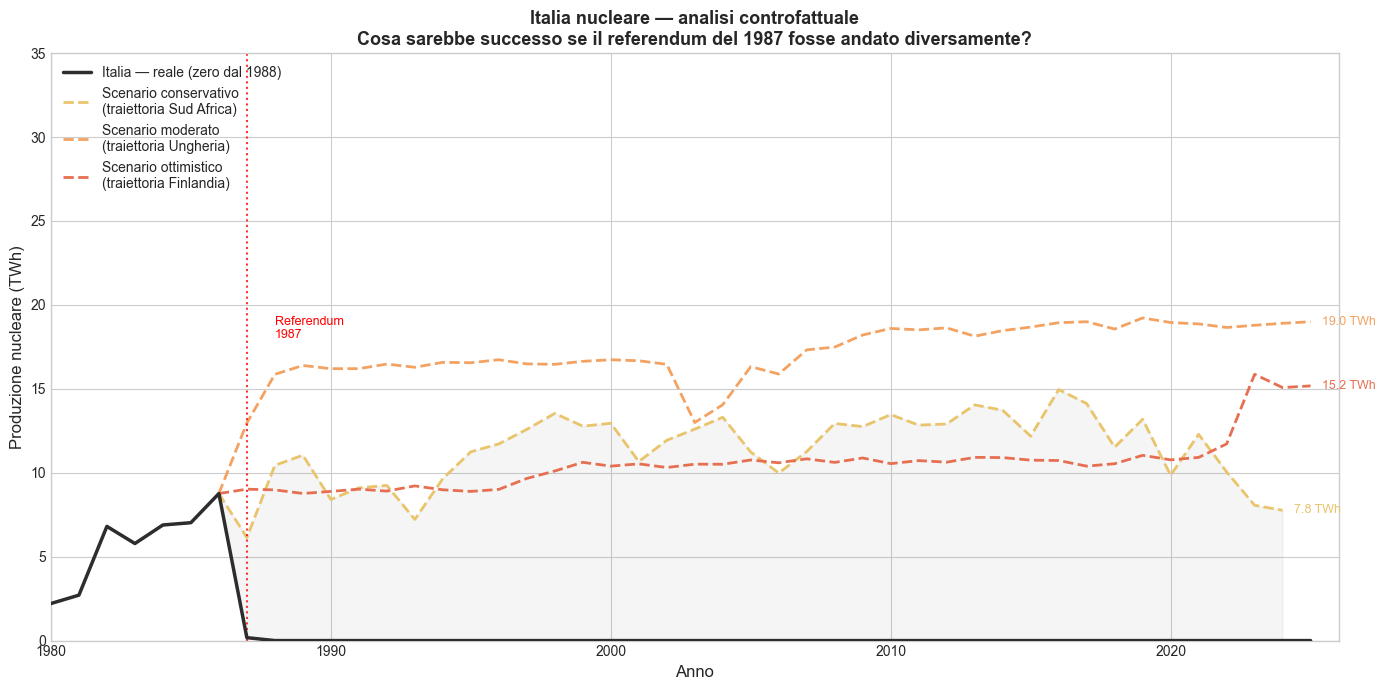

Grafico salvato in plots/


In [14]:
# Punto di partenza comune: Italia 1986
italy_1986 = 8.76

# Per ogni paese benchmark calcoliamo un fattore di scala
# rispetto al loro valore 1986, poi lo applichiamo all'Italia
benchmarks = {
    'South Africa': {'color': '#E9C46A', 'label': 'Scenario conservativo\n(traiettoria Sud Africa)'},
    'Hungary':      {'color': '#F4A261', 'label': 'Scenario moderato\n(traiettoria Ungheria)'},
    'Finland':      {'color': '#E76F51', 'label': 'Scenario ottimistico\n(traiettoria Finlandia)'},
}

fig, ax = plt.subplots(figsize=(14, 7))

# Linea reale Italia
df_italy = df_cf[df_cf['country'] == 'Italy']
ax.plot(df_italy['year'], df_italy['nuclear_twh'],
        color='#2d2d2d', linewidth=2.5, linestyle='-',
        label='Italia — reale (zero dal 1988)', zorder=5)

# Scenari controfattuali
for country, props in benchmarks.items():
    df_b = df_cf[df_cf['country'] == country].copy()
    b_1986 = df_b[df_b['year'] == 1986]['nuclear_twh'].values[0]
    
    # Scala la traiettoria del benchmark partendo dal punto italiano
    df_b['twh_scalato'] = df_b['nuclear_twh'] * (italy_1986 / b_1986)
    
    # Solo dal 1986 in poi
    df_b = df_b[df_b['year'] >= 1986]
    
    ax.plot(df_b['year'], df_b['twh_scalato'],
            color=props['color'], linewidth=2,
            linestyle='--', label=props['label'])
    
    # Etichetta valore finale
    last = df_b.iloc[-1]
    ax.annotate(f"{last['twh_scalato']:.1f} TWh",
                xy=(last['year'], last['twh_scalato']),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, color=props['color'], va='center')

# Linea verticale referendum
ax.axvline(x=1987, color='red', linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(1988, 18, 'Referendum\n1987', color='red', fontsize=9)

# Area tra scenario conservativo e reale
df_sa = df_cf[df_cf['country'] == 'South Africa'].copy()
df_sa = df_sa[df_sa['year'] >= 1986]
b_1986_sa = 8.80
df_sa['twh_scalato'] = df_sa['nuclear_twh'] * (italy_1986 / b_1986_sa)
ax.fill_between(df_sa['year'], 
                df_italy[df_italy['year'] >= 1986]['nuclear_twh'].values[:len(df_sa)],
                df_sa['twh_scalato'],
                alpha=0.08, color='gray', label='_nolegend_')

ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Produzione nucleare (TWh)', fontsize=12)
ax.set_title('Italia nucleare — analisi controfattuale\nCosa sarebbe successo se il referendum del 1987 fosse andato diversamente?',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(1980, 2026)
ax.set_ylim(0, 35)

plt.tight_layout()
plt.savefig('../plots/05_italia_controfattuale.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")

In [15]:
from scipy.ndimage import uniform_filter1d

italy_1986 = 8.76

benchmarks = {
    'South Africa': {'color': '#E9C46A', 'label': 'Scenario stagnante\n(traiettoria Sud Africa)'},
    'Hungary':      {'color': '#F4A261', 'label': 'Scenario moderato\n(traiettoria Ungheria)'},
    'Finland':      {'color': '#E76F51', 'label': 'Scenario ottimistico\n(traiettoria Finlandia)'},
}

fig, ax = plt.subplots(figsize=(14, 7))

# Linea reale Italia
df_italy = df_cf[df_cf['country'] == 'Italy']
ax.plot(df_italy['year'], df_italy['nuclear_twh'],
        color='#2d2d2d', linewidth=2.5, linestyle='-',
        label='Italia — reale (zero dal 1988)', zorder=5)

# Scenari con media mobile
for country, props in benchmarks.items():
    df_b = df_cf[df_cf['country'] == country].copy()
    b_1986 = df_b[df_b['year'] == 1986]['nuclear_twh'].values[0]
    df_b['twh_scalato'] = df_b['nuclear_twh'] * (italy_1986 / b_1986)
    df_b = df_b[df_b['year'] >= 1986].reset_index(drop=True)
    
    # Media mobile 5 anni per smussare
    df_b['twh_smooth'] = uniform_filter1d(df_b['twh_scalato'].values, 
                                           size=5, mode='nearest')
    
    ax.plot(df_b['year'], df_b['twh_smooth'],
            color=props['color'], linewidth=2.5,
            linestyle='--', label=props['label'])
    
    # Etichetta valore finale
    last = df_b.iloc[-1]
    ax.annotate(f"{last['twh_smooth']:.1f} TWh",
                xy=(last['year'], last['twh_smooth']),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, color=props['color'], va='center')

# Area grigia tra zero e scenario conservativo
df_sa = df_cf[df_cf['country'] == 'South Africa'].copy()
df_sa = df_sa[df_sa['year'] >= 1986].reset_index(drop=True)
b_1986_sa = 8.80
df_sa['twh_scalato'] = df_sa['nuclear_twh'] * (italy_1986 / b_1986_sa)
df_sa['twh_smooth'] = uniform_filter1d(df_sa['twh_scalato'].values,
                                        size=5, mode='nearest')
ax.fill_between(df_sa['year'], 0, df_sa['twh_smooth'],
                alpha=0.06, color='#E9C46A')

# Linea referendum
ax.axvline(x=1987, color='red', linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(1988, 22, 'Referendum\n1987', color='red', fontsize=9)

ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Produzione nucleare stimata (TWh)', fontsize=12)
ax.set_title('Italia nucleare — analisi controfattuale\n'
             'Cosa sarebbe successo se il referendum del 1987 fosse andato diversamente?',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(1980, 2026)
ax.set_ylim(0, 35)

# Nota metodologica
ax.text(0.98, 0.02,
        'Nota: scenari costruiti scalando le traiettorie reali dei paesi benchmark\n'
        'al punto di partenza italiano (8.76 TWh nel 1986)',
        transform=ax.transAxes, fontsize=8, color='gray',
        ha='right', va='bottom', style='italic')

plt.tight_layout()
plt.savefig('../plots/05_italia_controfattuale.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")

ModuleNotFoundError: No module named 'scipy'

In [16]:
from scipy.ndimage import uniform_filter1d

ModuleNotFoundError: No module named 'scipy'

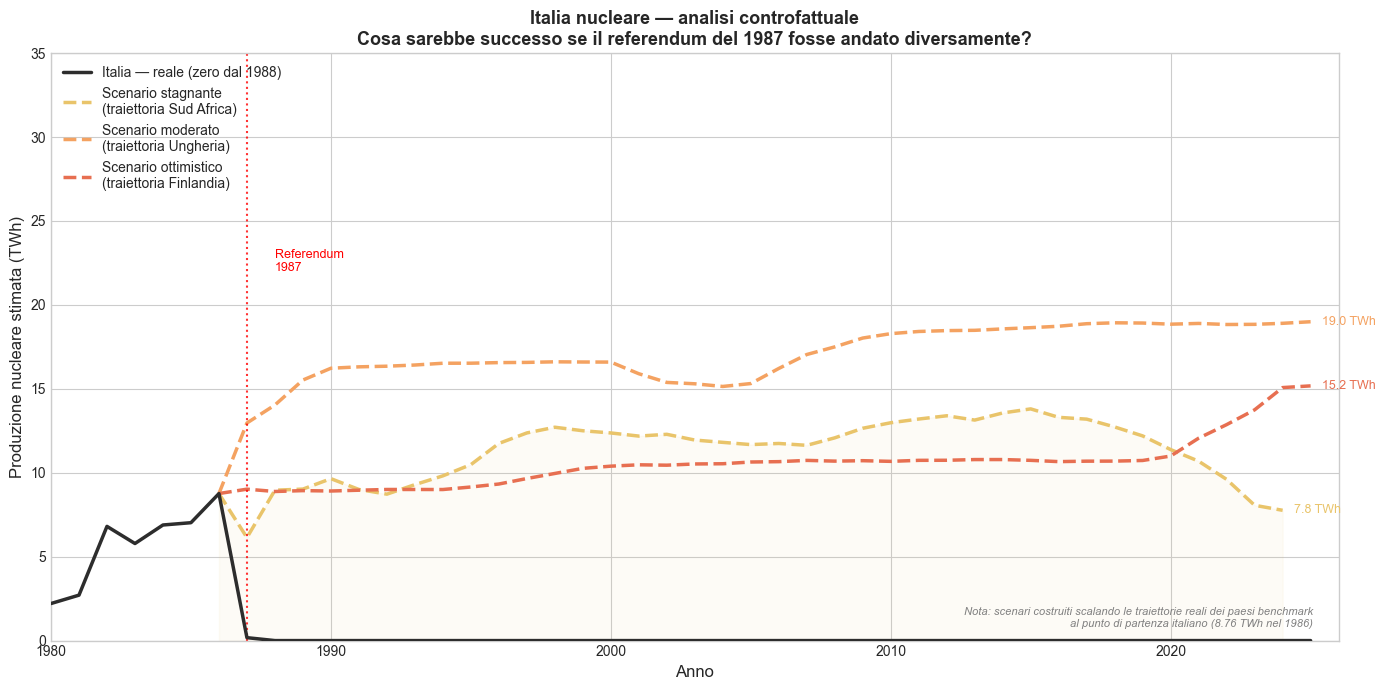

Grafico salvato in plots/


In [17]:
italy_1986 = 8.76

benchmarks = {
    'South Africa': {'color': '#E9C46A', 'label': 'Scenario stagnante\n(traiettoria Sud Africa)'},
    'Hungary':      {'color': '#F4A261', 'label': 'Scenario moderato\n(traiettoria Ungheria)'},
    'Finland':      {'color': '#E76F51', 'label': 'Scenario ottimistico\n(traiettoria Finlandia)'},
}

fig, ax = plt.subplots(figsize=(14, 7))

# Linea reale Italia
df_italy = df_cf[df_cf['country'] == 'Italy']
ax.plot(df_italy['year'], df_italy['nuclear_twh'],
        color='#2d2d2d', linewidth=2.5, linestyle='-',
        label='Italia — reale (zero dal 1988)', zorder=5)

# Scenari con media mobile
for country, props in benchmarks.items():
    df_b = df_cf[df_cf['country'] == country].copy()
    b_1986 = df_b[df_b['year'] == 1986]['nuclear_twh'].values[0]
    df_b['twh_scalato'] = df_b['nuclear_twh'] * (italy_1986 / b_1986)
    df_b = df_b[df_b['year'] >= 1986].reset_index(drop=True)

    # Media mobile 5 anni per smussare
    df_b['twh_smooth'] = df_b['twh_scalato'].rolling(window=5, center=True).mean()
    df_b['twh_smooth'] = df_b['twh_smooth'].fillna(df_b['twh_scalato'])

    ax.plot(df_b['year'], df_b['twh_smooth'],
            color=props['color'], linewidth=2.5,
            linestyle='--', label=props['label'])

    # Etichetta valore finale
    last = df_b.iloc[-1]
    ax.annotate(f"{last['twh_smooth']:.1f} TWh",
                xy=(last['year'], last['twh_smooth']),
                xytext=(8, 0), textcoords='offset points',
                fontsize=9, color=props['color'], va='center')

# Area grigia tra zero e scenario conservativo
df_sa = df_cf[df_cf['country'] == 'South Africa'].copy()
df_sa = df_sa[df_sa['year'] >= 1986].reset_index(drop=True)
b_1986_sa = 8.80
df_sa['twh_scalato'] = df_sa['nuclear_twh'] * (italy_1986 / b_1986_sa)
df_sa['twh_smooth'] = df_sa['twh_scalato'].rolling(window=5, center=True).mean()
df_sa['twh_smooth'] = df_sa['twh_smooth'].fillna(df_sa['twh_scalato'])
ax.fill_between(df_sa['year'], 0, df_sa['twh_smooth'],
                alpha=0.06, color='#E9C46A')

# Linea referendum
ax.axvline(x=1987, color='red', linestyle=':', linewidth=1.5, alpha=0.8)
ax.text(1988, 22, 'Referendum\n1987', color='red', fontsize=9)

ax.set_xlabel('Anno', fontsize=12)
ax.set_ylabel('Produzione nucleare stimata (TWh)', fontsize=12)
ax.set_title('Italia nucleare — analisi controfattuale\n'
             'Cosa sarebbe successo se il referendum del 1987 fosse andato diversamente?',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')
ax.set_xlim(1980, 2026)
ax.set_ylim(0, 35)

# Nota metodologica
ax.text(0.98, 0.02,
        'Nota: scenari costruiti scalando le traiettorie reali dei paesi benchmark\n'
        'al punto di partenza italiano (8.76 TWh nel 1986)',
        transform=ax.transAxes, fontsize=8, color='gray',
        ha='right', va='bottom', style='italic')

plt.tight_layout()
plt.savefig('../plots/05_italia_controfattuale.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafico salvato in plots/")